# Step 5d: Interpreting Fingerprint Bits - What Do The 1's Mean?
Explanation Script: "Now let's understand what those fingerprint bits actually mean. When you see [0 0 1 0 0 1 0 0...], each position corresponds to a specific molecular substructure. A '1' means that substructure exists in the molecule. A '0' means it does not. Let's visualize this."

Chloroquine fingerprint first 20 bits:
[1 1 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1]

Number of 1's in first 20 bits: 6
Number of 0's in first 20 bits: 14

Positions with value 1 in first 20 bits:
  Bit 0 = 1
  Bit 1 = 1
  Bit 2 = 1
  Bit 11 = 1
  Bit 17 = 1
  Bit 19 = 1

Chloroquine structure (atoms numbered):


[19:13:16] DEPRECATION WARNING: please use MorganGenerator


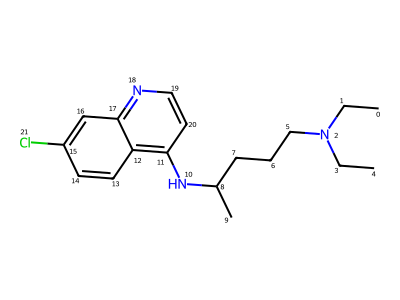

In [1]:

from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import IPythonConsole
import numpy as np

# chloroquine 
smiles = "CCN(CC)CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl"
mol = Chem.MolFromSmiles(smiles)

# Generate fingerprint with bit info
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=128)
fp_array = np.array(list(fp))

print("Chloroquine fingerprint first 20 bits:")
print(fp_array[:20])
print(f"\nNumber of 1's in first 20 bits: {sum(fp_array[:20])}")
print(f"Number of 0's in first 20 bits: {20 - sum(fp_array[:20])}")

# Show which bits are 1
print("\nPositions with value 1 in first 20 bits:")
for i, val in enumerate(fp_array[:20]):
    if val == 1:
        print(f"  Bit {i} = 1")

# Draw the molecule with atom numbers
print("\nChloroquine structure (atoms numbered):")
mol_with_numbers = Chem.Mol(mol)
for atom in mol_with_numbers.GetAtoms():
    atom.SetProp('atomNote', str(atom.GetIdx()))
Draw.MolToImage(mol_with_numbers, size=(400, 300))



Explanation Script Continues:

"Each '1' in positions 0, 1, 2, 11, 17, and 19 means chloroquine contains specific substructures centered around certain atoms in the molecule. 

For example, one bit may represent the quinoline aromatic ring system, which is a key structural feature of chloroquine. Another bit may represent the secondary amine linker that connects the aromatic ring to the side chain. Other bits may correspond to the tertiary amine group in the side chain or the chlorine substitution on the aromatic ring.

The Morgan fingerprint works like a structural checklist: it asks whether the molecule contains certain atom environments or molecular fragments within a defined radius around each atom.

So the fingerprint is essentially answering questions such as:  
Does this molecule contain an aromatic ring environment?  
Does it contain nitrogen-containing functional groups?  
Does it contain specific carbon–nitrogen bonding patterns?

Machine learning models use this checklist of structural patterns to compare molecules and learn which molecular features are associated with biological activity, such as antimalarial properties."